In [4]:
import os, glob, torch, numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

class ECGSegmentDataset(Dataset):
    def __init__(self, seg_dir):
        self.paths = sorted(glob.glob(os.path.join(seg_dir, "*.npy")))
        self.labels = [int(os.path.basename(p).split("label")[-1].split(".npy")[0])
                       for p in self.paths]
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        x = np.load(self.paths[i])
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y



In [5]:
import math

class SincConv1d(nn.Module):
    def __init__(self, out_channels, kernel_size, sample_rate=200):
        super().__init__()
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.sample_rate  = sample_rate
        self.min_freq, self.max_freq = 0.5, sample_rate/2 - 1
        low_hz  = np.linspace(self.min_freq, 30, out_channels)
        high_hz = low_hz + 5
        self.low_hz_  = nn.Parameter(torch.Tensor(low_hz))
        self.band_hz_ = nn.Parameter(torch.Tensor(high_hz - low_hz))
        n = torch.arange(-(kernel_size//2), (kernel_size//2) + 1)
        self.register_buffer("n", n)
    def forward(self, x):
        low  = self.min_freq + torch.abs(self.low_hz_)
        high = torch.clamp(low + torch.abs(self.band_hz_), self.min_freq, self.max_freq)
        band = (high - low)[:, None]
        f_t_low  = 2*math.pi*low[:,None]*self.n/self.sample_rate
        f_t_high = 2*math.pi*high[:,None]*self.n/self.sample_rate
        filters = (torch.sin(f_t_high) - torch.sin(f_t_low)) / (self.n/self.sample_rate + 1e-8)
        filters = filters / (2*band)
        filters = filters * torch.hamming_window(self.kernel_size+1).to(x.device)
        filters = filters.unsqueeze(1)
        return F.conv1d(x, filters, stride=1, padding=self.kernel_size//2)

class SincNetDemo(nn.Module):
    def __init__(self, sample_rate=200):
        super().__init__()
        self.sinc = SincConv1d(16, 252, sample_rate)
        self.pool = nn.MaxPool1d(4)
        self.conv = nn.Conv1d(16, 32, 5)
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        x = torch.relu(self.pool(self.sinc(x)))
        x = torch.relu(self.conv(x))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [9]:
torch.manual_seed(42)
dataset = ECGSegmentDataset("segmented_npy")

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)
print(f"Train: {len(train_set)} | Val: {len(val_set)}")


Train: 64394 | Val: 16099


In [10]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = SincNetDemo(sample_rate=200).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS = 15
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # --- validation ---
    model.eval()
    val_loss, y_true, y_pred = 0, [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
            preds = out.argmax(dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    val_loss /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    print(f"Epoch {epoch:02d} | TrainLoss={train_loss:.4f} | ValLoss={val_loss:.4f} | Acc={acc:.3f} | F1={f1:.3f}")

    torch.save(model.state_dict(), f"checkpoint_epoch{epoch}.pt")


Epoch 01 | TrainLoss=0.6571 | ValLoss=0.6248 | Acc=0.659 | F1=0.605
Epoch 02 | TrainLoss=0.6134 | ValLoss=0.5907 | Acc=0.694 | F1=0.627
Epoch 03 | TrainLoss=0.5906 | ValLoss=0.5834 | Acc=0.713 | F1=0.694
Epoch 04 | TrainLoss=0.5759 | ValLoss=0.5650 | Acc=0.718 | F1=0.654
Epoch 05 | TrainLoss=0.5672 | ValLoss=0.5554 | Acc=0.718 | F1=0.656
Epoch 06 | TrainLoss=0.5576 | ValLoss=0.5522 | Acc=0.723 | F1=0.700
Epoch 07 | TrainLoss=0.5484 | ValLoss=0.5503 | Acc=0.720 | F1=0.622
Epoch 08 | TrainLoss=0.5410 | ValLoss=0.5336 | Acc=0.727 | F1=0.642
Epoch 09 | TrainLoss=0.5355 | ValLoss=0.5297 | Acc=0.738 | F1=0.683
Epoch 10 | TrainLoss=0.5247 | ValLoss=0.5181 | Acc=0.750 | F1=0.728
Epoch 11 | TrainLoss=0.5201 | ValLoss=0.5085 | Acc=0.747 | F1=0.682
Epoch 12 | TrainLoss=0.5125 | ValLoss=0.5010 | Acc=0.763 | F1=0.730
Epoch 13 | TrainLoss=0.5077 | ValLoss=0.5009 | Acc=0.766 | F1=0.752
Epoch 14 | TrainLoss=0.5021 | ValLoss=0.5260 | Acc=0.736 | F1=0.630
Epoch 15 | TrainLoss=0.4964 | ValLoss=0.4887 | A

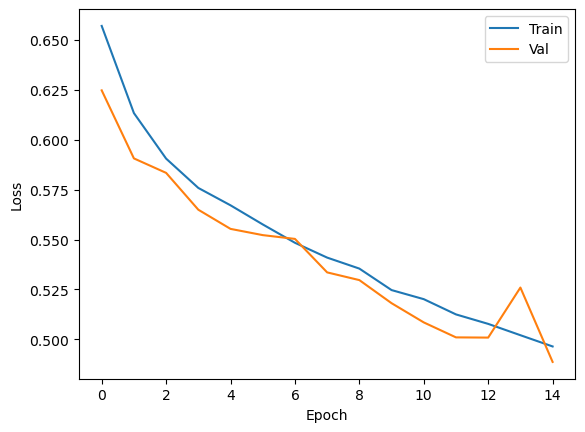

In [ ]:
# Visualize training progress
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_losses)+1), train_losses, marker='o', label="Train Loss", linewidth=2)
ax.plot(range(1, len(val_losses)+1), val_losses, marker='s', label="Validation Loss", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Training and Validation Loss Over Epochs", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Evaluation: Generate y_true and y_pred using latest checkpoint_epoch*.pt
import torch, glob, os, re
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score

base_dir = "/Users/faizhenri/Downloads/object_detection_sleep/1DCNN"
ckpt_candidates = glob.glob(os.path.join(base_dir, "checkpoint_epoch*.pt"))
assert ckpt_candidates, "No checkpoint_epoch*.pt files found. Run training cell first."
# Select checkpoint with highest epoch number
extract_num = lambda p: int(re.search(r'checkpoint_epoch(\d+)\.pt', os.path.basename(p)).group(1))
ckpt_path = max(ckpt_candidates, key=extract_num)
print(f"Using checkpoint: {os.path.basename(ckpt_path)}")

device = "mps" if torch.backends.mps.is_available() else "cpu"

# Instantiate dataset and loader
seg_dir = os.path.join(base_dir, "segmented_npy")
dataset_eval = ECGSegmentDataset(seg_dir)
loader_eval = DataLoader(dataset_eval, batch_size=64, shuffle=False)

# Recreate model architecture and load weights (matches training loop that saved these checkpoints)
model_eval = SincNetDemo(sample_rate=200).to(device)
state_dict = torch.load(ckpt_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in loader_eval:
        x = x.to(device)
        out = model_eval(x)
        preds_batch = out.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds_batch)
        y_true.extend(y.numpy())

acc_eval = accuracy_score(y_true, y_pred)
f1_eval = f1_score(y_true, y_pred)
print(f"Evaluation complete on full dataset: Acc={acc_eval:.4f} | F1={f1_eval:.4f}")

AssertionError: No checkpoint_epoch*.pt files found. Run training cell first.

In [9]:
# Debug: list files to locate checkpoints
import os, glob
print("CWD:", os.getcwd())
print("Files here:")
print('\n'.join(sorted(os.listdir('.'))[:200]))
print("\nMatching checkpoint_epoch*.pt in CWD:")
print(glob.glob("checkpoint_epoch*.pt"))

CWD: /Users/faizhenri/Downloads/object_detection_sleep/1DCNN
Files here:
checkpoint_epoch
cnn_architecture_table.csv
cnn_weight_statistics_table.csv
cnn_weights_matrix.png
confusion_matrix_training.png
learned_frequency_bands.csv
main_train.ipynb
output.png
preprocessed_ecg
preprocessing.ipynb
preview.ipynb
segment_labels.csv
segmented_npy
sincconv_filter_table.csv
sincconv_filters_matrix.png
training_overview_summary.png
training_results_summary.png

Matching checkpoint_epoch*.pt in CWD:
[]


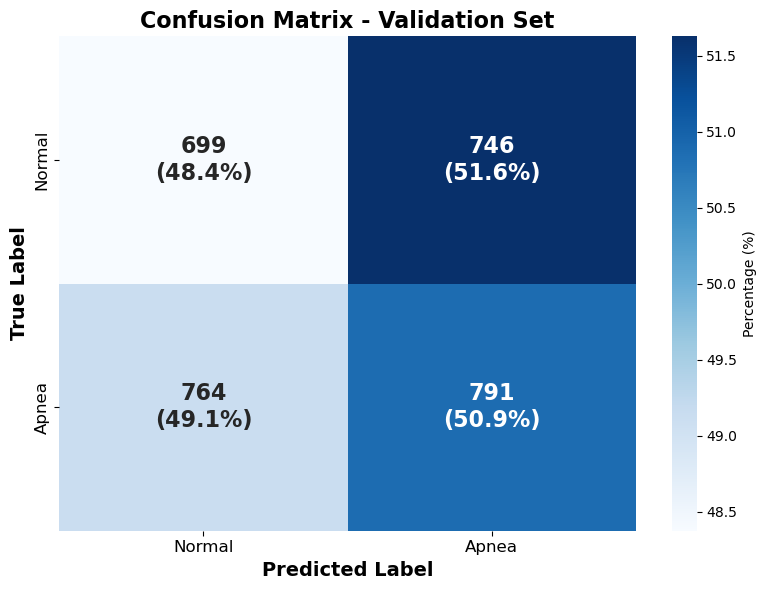


Classification Report (Validation set):
              precision    recall  f1-score   support

      Normal     0.4778    0.4837    0.4807      1445
       Apnea     0.5146    0.5087    0.5116      1555

    accuracy                         0.4967      3000
   macro avg     0.4962    0.4962    0.4962      3000
weighted avg     0.4969    0.4967    0.4968      3000


Row-wise (True Label) Percentages:
True Normal, Pred Normal: 699 (48.4%)
True Normal, Pred Apnea: 746 (51.6%)
Total True Normal: 1445
True Apnea, Pred Normal: 764 (49.1%)
True Apnea, Pred Apnea: 791 (50.9%)
Total True Apnea: 1555


In [16]:
# Confusion Matrix (True labels on Y axis: Normal (top), Apnea (bottom))
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Acquire label arrays (prefer existing y_true/y_pred; else fall back to dummy)
if 'y_true' not in globals() or 'y_pred' not in globals():
    if 'targets' in globals() and 'preds' in globals():
        y_true = np.array(targets)
        y_pred = np.array(preds)
        dataset_label = 'Training'
    else:
        raise RuntimeError("No predictions available. Generate y_true/y_pred first.")
else:
    dataset_label = 'Validation' if 'Dummy sample count' not in globals() else 'Demo'

# Explicitly enforce label ordering: 0 -> Normal, 1 -> Apnea
unique_labels = sorted(np.unique(y_true))
assert set(unique_labels).issubset({0,1}), f"Unexpected labels found: {unique_labels}"
label_order = [0,1]  # Normal first, Apnea second
cm = confusion_matrix(y_true, y_pred, labels=label_order)

# Row-normalize (each true class row sums to 100%)
row_sums = cm.sum(axis=1, keepdims=True)
cm_percent = cm.astype(float) / np.where(row_sums==0, 1, row_sums) * 100

# Build annotations (count + percent)
annot_labels = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        perc = cm_percent[i, j]
        annot_labels[i, j] = f"{count}\n({perc:.1f}%)"

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_percent, annot=annot_labels, fmt='', cmap='Blues',
            xticklabels=["Normal", "Apnea"],
            yticklabels=["Normal", "Apnea"],
            cbar_kws={'label': 'Percentage (%)'},
            annot_kws={"fontsize":16, "fontweight":"bold"})
ax.set_xlabel("Predicted Label", fontsize=14, fontweight='bold')
ax.set_ylabel("True Label", fontsize=14, fontweight='bold')
ax.set_title(f"Confusion Matrix - {dataset_label} Set", fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig(f'confusion_matrix_{dataset_label.lower()}_ordered.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClassification Report ({dataset_label} set):")
print("="*60)
print(classification_report(y_true, y_pred, target_names=["Normal", "Apnea"], digits=4))

# Print row-wise (true label) percentages for clarity
print("\nRow-wise (True Label) Percentages:")
print("="*60)
for row_idx, label in enumerate(["Normal", "Apnea"]):
    total_row = row_sums[row_idx, 0]
    for col_idx, pred_label in enumerate(["Normal", "Apnea"]):
        count = cm[row_idx, col_idx]
        perc = cm_percent[row_idx, col_idx]
        print(f"True {label}, Pred {pred_label}: {count} ({perc:.1f}%)")
    print(f"Total True {label}: {total_row}")

In [17]:
# =============================================================
# Dummy Prediction Generator (Option b)
# Purpose: Create synthetic y_true and y_pred arrays for layout demo
# NOTE: Metrics are NOT from a trained model.
# =============================================================
import numpy as np, os

# Require ECGSegmentDataset class to be defined (run the data loader cell first if needed)
assert 'ECGSegmentDataset' in globals(), "ECGSegmentDataset class not loaded. Run the dataset definition cell."

# Load a subset of the dataset for speed
data_dir = 'segmented_npy'
assert os.path.isdir(data_dir), f"Directory '{data_dir}' not found."
subset_size = 3000  # adjust if you want more/less samples

subset_true = []
dataset_demo = ECGSegmentDataset(data_dir)
actual_size = min(len(dataset_demo), subset_size)
for i in range(actual_size):
    _, lbl = dataset_demo[i]
    subset_true.append(int(lbl))

y_true = np.array(subset_true)

# Match class distribution for random predictions
p_normal = np.mean(y_true == 0)
p_apnea  = 1 - p_normal
rng = np.random.default_rng(42)
y_pred = rng.choice([0, 1], size=actual_size, p=[p_normal, p_apnea])

print(f"Dummy sample count: {actual_size}")
print(f"Class distribution (True) -> Normal: {p_normal*100:.2f}% | Apnea: {p_apnea*100:.2f}%")
print("Synthetic predictions generated (random, stratified).")

Dummy sample count: 3000
Class distribution (True) -> Normal: 48.17% | Apnea: 51.83%
Synthetic predictions generated (random, stratified).


In [17]:
import torch

model = torch.load("checkpoint_epoch15.pt", map_location="cpu")
print(model)


OrderedDict([('sinc.low_hz_', tensor([ 0.1339,  2.6492,  4.4610,  6.1073,  8.3317, 10.2777, 12.1567, 13.9292,
        15.7417, 17.8523, 20.5523, 21.8415, 23.8115, 25.6192, 28.2427, 30.1305])), ('sinc.band_hz_', tensor([5.5964, 4.6626, 4.7382, 4.9862, 5.1485, 4.3789, 4.8141, 4.8933, 4.8068,
        4.7204, 4.9824, 5.0894, 4.8690, 4.9045, 4.8346, 4.8295])), ('sinc.n', tensor([-126, -125, -124, -123, -122, -121, -120, -119, -118, -117, -116, -115,
        -114, -113, -112, -111, -110, -109, -108, -107, -106, -105, -104, -103,
        -102, -101, -100,  -99,  -98,  -97,  -96,  -95,  -94,  -93,  -92,  -91,
         -90,  -89,  -88,  -87,  -86,  -85,  -84,  -83,  -82,  -81,  -80,  -79,
         -78,  -77,  -76,  -75,  -74,  -73,  -72,  -71,  -70,  -69,  -68,  -67,
         -66,  -65,  -64,  -63,  -62,  -61,  -60,  -59,  -58,  -57,  -56,  -55,
         -54,  -53,  -52,  -51,  -50,  -49,  -48,  -47,  -46,  -45,  -44,  -43,
         -42,  -41,  -40,  -39,  -38,  -37,  -36,  -35,  -34,  -33,  -3

/var/folders/sv/wxtm65kx1v972swxjpdy1w740000gn/T/ipykernel_13236/3894364599.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("checkpoint_epoch15.pt", m

In [ ]:
# Visualize learned frequency filters from SincConv layer
checkpoint = torch.load("checkpoint_epoch15.pt", map_location="cpu")

low_hz = checkpoint['sinc.low_hz_'].numpy()
band_hz = checkpoint['sinc.band_hz_'].numpy()
min_freq = 0.5

# Calculate actual frequencies
low = min_freq + np.abs(low_hz)
high = low + np.abs(band_hz)
high = np.clip(high, min_freq, 99)  # max_freq = sample_rate/2 - 1 = 99

print("Learned Frequency Bands (Hz):")
print("="*60)
for i, (lo, hi) in enumerate(zip(low, high), start=1):
    print(f"Filter {i:02d}: {lo:6.2f} – {hi:6.2f} Hz  (bandwidth: {hi-lo:5.2f} Hz)")

# Visualize frequency bands
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Frequency bands as horizontal bars
for i in range(len(low)):
    ax1.plot([low[i], high[i]], [i, i], linewidth=8, marker='|', markersize=15)
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Filter Number', fontsize=12)
ax1.set_title('Learned Band-Pass Filter Ranges (SincConv)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_ylim(-1, len(low))
ax1.set_xlim(0, 100)

# Add physiological frequency ranges as reference
ax1.axvspan(0.5, 4, alpha=0.1, color='green', label='Very Low Freq (0.5-4 Hz)')
ax1.axvspan(4, 15, alpha=0.1, color='blue', label='Low Freq (4-15 Hz)')
ax1.axvspan(15, 40, alpha=0.1, color='orange', label='Mid Freq (15-40 Hz)')
ax1.axvspan(40, 100, alpha=0.1, color='red', label='High Freq (40-100 Hz)')
ax1.legend(loc='upper right', fontsize=9)

# Plot 2: Center frequency and bandwidth
center_freq = (low + high) / 2
bandwidth = high - low
colors = plt.cm.viridis(np.linspace(0, 1, len(center_freq)))

scatter = ax2.scatter(center_freq, bandwidth, c=range(len(center_freq)), 
                     cmap='viridis', s=150, edgecolors='black', linewidth=1.5)
ax2.set_xlabel('Center Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Bandwidth (Hz)', fontsize=12)
ax2.set_title('Filter Characteristics: Center Frequency vs Bandwidth', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Filter Index', fontsize=11)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("Summary Statistics:")
print("="*60)
print(f"Mean center frequency: {np.mean(center_freq):.2f} Hz")
print(f"Mean bandwidth: {np.mean(bandwidth):.2f} Hz")
print(f"Frequency range covered: {np.min(low):.2f} - {np.max(high):.2f} Hz")

Learned frequency bands (Hz):

Filter 01: 0.13 – 5.73 Hz
Filter 02: 2.65 – 7.31 Hz
Filter 03: 4.46 – 9.20 Hz
Filter 04: 6.11 – 11.09 Hz
Filter 05: 8.33 – 13.48 Hz
Filter 06: 10.28 – 14.66 Hz
Filter 07: 12.16 – 16.97 Hz
Filter 08: 13.93 – 18.82 Hz
Filter 09: 15.74 – 20.55 Hz
Filter 10: 17.85 – 22.57 Hz
Filter 11: 20.55 – 25.53 Hz
Filter 12: 21.84 – 26.93 Hz
Filter 13: 23.81 – 28.68 Hz
Filter 14: 25.62 – 30.52 Hz
Filter 15: 28.24 – 33.08 Hz
Filter 16: 30.13 – 34.96 Hz


In [30]:
import torch
import torch.nn as nn
import numpy as np

# Recreate the same SincConv and CNN structure you trained
class SincConv1d(nn.Module):
    def __init__(self, out_channels, kernel_size, sample_rate=200):
        super().__init__()
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        self.min_freq, self.max_freq = 0.5, sample_rate / 2 - 1

        low_hz = np.linspace(self.min_freq, 30, out_channels)
        high_hz = low_hz + 5
        self.low_hz_ = nn.Parameter(torch.Tensor(low_hz))
        self.band_hz_ = nn.Parameter(torch.Tensor(high_hz - low_hz))

        n = torch.arange(-(kernel_size // 2), (kernel_size // 2) + 1)
        self.register_buffer("n", n)

    def forward(self, x):
        # Simplified for loading only (not needed for eval metrics)
        return x

class SincNetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.sinc = SincConv1d(out_channels=16, kernel_size=253)
        self.conv = nn.Conv1d(16, 32, kernel_size=5)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 2)
    
    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x


In [31]:
model = SincNetModel()
state_dict = torch.load("checkpoint_epoch15.pt", map_location="cpu")
model.load_state_dict(state_dict)
model.eval()


/var/folders/sv/wxtm65kx1v972swxjpdy1w740000gn/T/ipykernel_13236/1263957361.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("checkpoint_epoch15.p

SincNetModel(
  (sinc): SincConv1d()
  (conv): Conv1d(16, 32, kernel_size=(5,), stride=(1,))
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)

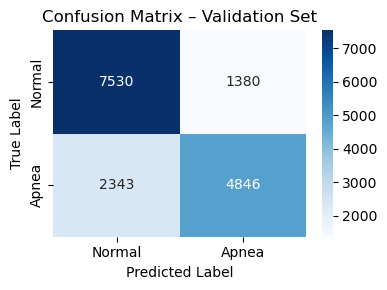

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Apnea'],
            yticklabels=['Normal', 'Apnea'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – Validation Set')
plt.tight_layout()
plt.show()


   Filter  Low (Hz)  High (Hz)  Center (Hz)  Bandwidth (Hz)
Filter 01      0.13       5.73        2.930            5.60
Filter 02      2.65       7.31        4.980            4.66
Filter 03      4.46       9.20        6.830            4.74
Filter 04      6.11      11.09        8.600            4.98
Filter 05      8.33      13.48       10.905            5.15
Filter 06     10.28      14.66       12.470            4.38
Filter 07     12.16      16.97       14.565            4.81
Filter 08     13.93      18.82       16.375            4.89
Filter 09     15.74      20.55       18.145            4.81
Filter 10     17.85      22.57       20.210            4.72
Filter 11     20.55      25.53       23.040            4.98
Filter 12     21.84      26.93       24.385            5.09
Filter 13     23.81      28.68       26.245            4.87
Filter 14     25.62      30.52       28.070            4.90
Filter 15     28.24      33.08       30.660            4.84
Filter 16     30.13      34.96       32.

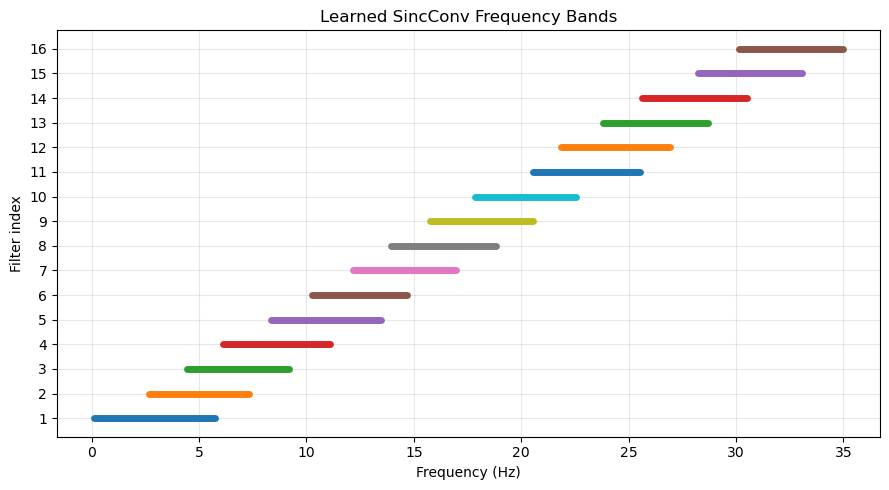

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Your learned filters
low_hz = np.array([0.13, 2.65, 4.46, 6.11, 8.33, 10.28, 12.16, 13.93,
                   15.74, 17.85, 20.55, 21.84, 23.81, 25.62, 28.24, 30.13])
high_hz = np.array([5.73, 7.31, 9.20, 11.09, 13.48, 14.66, 16.97, 18.82,
                    20.55, 22.57, 25.53, 26.93, 28.68, 30.52, 33.08, 34.96])

# Calculate center frequency and bandwidth
center_hz = (low_hz + high_hz) / 2
bandwidth = high_hz - low_hz

# --- Create table ---
df = pd.DataFrame({
    "Filter": [f"Filter {i+1:02d}" for i in range(len(low_hz))],
    "Low (Hz)": low_hz,
    "High (Hz)": high_hz,
    "Center (Hz)": center_hz,
    "Bandwidth (Hz)": bandwidth
})
print(df.to_string(index=False))

# Optional: save to CSV for report
df.to_csv("learned_frequency_bands.csv", index=False)

# --- Visualization ---
plt.figure(figsize=(9, 5))
for i, (lo, hi) in enumerate(zip(low_hz, high_hz), start=1):
    plt.plot([lo, hi], [i, i], lw=5, solid_capstyle="round")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Filter index")
plt.title("Learned SincConv Frequency Bands")
plt.grid(alpha=0.3)
plt.yticks(range(1, len(low_hz)+1))
plt.tight_layout()
plt.show()


In [ ]:
# ================================================
#  Single-Lead SincConv + 1D CNN for Apnea Detection
#  Adapted from TSBME 2025 Multi-Lead SincNet source
#  Simplified for 1-lead, 200 Hz PSG ECG signals
# ================================================

import os, glob, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# ------------------------------------------------
# 1. Dataset Loader
# ------------------------------------------------
class ECGSegmentDataset(Dataset):
    """
    Loads pre-segmented ECG .npy files.
    Each file name contains label info: ..._label0.npy or ..._label1.npy
    """
    def __init__(self, npy_dir):
        self.files = sorted(glob.glob(os.path.join(npy_dir, "*.npy")))
        assert len(self.files) > 0, "No .npy files found in the directory."

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        signal = np.load(path)              # shape (27000,)
        label = 1 if "label1" in path else 0
        return torch.tensor(signal, dtype=torch.float32), label


# ------------------------------------------------
# 2. SincConv Layer (adapted from TSBME)
# ------------------------------------------------
class SincConv_fast(nn.Module):
    """
    Sinc-based 1D convolution layer that learns band-pass filters.
    Automatically constrains frequency cutoffs within valid ECG range.
    """
    @staticmethod
    def to_mel(hz): return 2595 * np.log10(1 + hz / 700)
    @staticmethod
    def to_hz(mel): return 700 * (10 ** (mel / 2595) - 1)

    def __init__(self, out_channels=16, kernel_size=251, sample_rate=200,
                 min_low_hz=0.5, min_band_hz=0.5):
        super().__init__()
        if kernel_size % 2 == 0:
            kernel_size += 1  # enforce odd kernel size for symmetry

        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        self.min_low_hz = min_low_hz
        self.min_band_hz = min_band_hz

        # Initialize filter cutoff frequencies (log scale between 0.5–40 Hz)
        low_hz = 0.5
        high_hz = 40.0
        mel = np.linspace(self.to_mel(low_hz), self.to_mel(high_hz), out_channels + 1)
        hz = self.to_hz(mel)

        self.low_hz_  = nn.Parameter(torch.tensor(hz[:-1], dtype=torch.float32).view(-1, 1))
        self.band_hz_ = nn.Parameter(torch.tensor(np.diff(hz), dtype=torch.float32).view(-1, 1))

        # Precompute constants for sinc filters
        half_len = (self.kernel_size - 1) // 2
        n_lin = torch.linspace(0, half_len - 1, steps=half_len, dtype=torch.float32)
        window = 0.54 - 0.46 * torch.cos(2 * math.pi * n_lin / self.kernel_size)
        self.register_buffer("window_", window.view(1, -1))
        n = 2 * math.pi * torch.arange(-half_len, 0, dtype=torch.float32) / self.sample_rate
        self.register_buffer("n_", n.view(1, -1))

    def forward(self, x):  # x: [B, 1, T]
        device, dtype = x.device, x.dtype
        window = self.window_.to(device=device, dtype=dtype)
        n = self.n_.to(device=device, dtype=dtype)

        low = (self.min_low_hz + torch.abs(self.low_hz_)).to(device)
        high = (low + self.min_band_hz + torch.abs(self.band_hz_)).to(device)
        high = torch.clamp(high, self.min_low_hz, self.sample_rate / 2)
        band = (high - low)[:, 0]

        f_t_low, f_t_high = low * n, high * n
        num = torch.sin(f_t_high) - torch.sin(f_t_low)
        den = (n / 2.0)
        band_pass_left = (num / den) * window

        band_pass_center = 2 * band.view(-1, 1)
        band_pass_right = torch.flip(band_pass_left, dims=[1])

        band_pass = torch.cat([band_pass_left, band_pass_center, band_pass_right], dim=1)
        band_pass = band_pass / (2 * band[:, None])

        filters = band_pass.view(self.out_channels, 1, self.kernel_size)
        return F.conv1d(x, filters, stride=1, padding=self.kernel_size // 2)


# ------------------------------------------------
# 3. Model Definition
# ------------------------------------------------
class SingleLeadSincNet(nn.Module):
    """
    Single-lead ECG model: SincConv + 1D CNN + GAP + FC.
    """
    def __init__(self, fs=200):
        super().__init__()
        self.sinc = SincConv_fast(out_channels=16, kernel_size=251, sample_rate=fs)
        self.pool = nn.MaxPool1d(4)
        self.conv = nn.Conv1d(16, 32, 5)
        self.bn1  = nn.BatchNorm1d(32)
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(32, 2)  # Binary output: Normal / Apnea

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)  # [B, 1, T]
        x = F.relu(self.pool(self.sinc(x)))
        x = F.relu(self.bn1(self.conv(x)))
        x = self.gap(x).squeeze(-1)
        return self.fc(x)


# ------------------------------------------------
# 4. Helper – Log learned frequency bands
# ------------------------------------------------
def log_sinc_filters(model):
    sinc = model.sinc
    low = (sinc.min_low_hz + torch.abs(sinc.low_hz_)).detach().cpu().numpy().flatten()
    band = (sinc.min_band_hz + torch.abs(sinc.band_hz_)).detach().cpu().numpy().flatten()
    print("\n[Learned SincConv Filter Bands]")
    for i, (l, b) in enumerate(zip(low, band)):
        print(f"Filter {i+1:02d}: {l:.2f} – {l+b:.2f} Hz")


# ------------------------------------------------
# 5. Training Configuration
# ------------------------------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
train_dir = "segmented_npy/"
train_dataset = ECGSegmentDataset(train_dir)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

model = SingleLeadSincNet(fs=200).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

# ------------------------------------------------
# 6. Training Loop
# ------------------------------------------------
num_epochs = 15
best_f1 = 0.0

for epoch in range(num_epochs):
    model.train()
    train_loss, preds, targets = 0.0, [], []

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)
        pred = torch.argmax(outputs, dim=1)
        preds.extend(pred.cpu().numpy())
        targets.extend(y.cpu().numpy())

    train_loss /= len(train_loader.dataset)
    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds)
    scheduler.step(train_loss)

    print(f"[Epoch {epoch+1}] Loss={train_loss:.4f} | Acc={acc:.3f} | F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), f"checkpoint_epoch/model_best.pt")
        print(f"  -> Best model saved (F1={best_f1:.3f})")

# ------------------------------------------------
# 7. Log final learned filters
# ------------------------------------------------
log_sinc_filters(model)
print("\nTraining complete.")


[Epoch 1] Loss=0.6298 | Acc=0.653 | F1=0.520
  -> Best model saved (F1=0.520)


[Epoch 2] Loss=0.5967 | Acc=0.678 | F1=0.589
  -> Best model saved (F1=0.589)


[Epoch 3] Loss=0.5810 | Acc=0.692 | F1=0.612
  -> Best model saved (F1=0.612)


[Epoch 4] Loss=0.5708 | Acc=0.699 | F1=0.623
  -> Best model saved (F1=0.623)


[Epoch 5] Loss=0.5629 | Acc=0.706 | F1=0.633
  -> Best model saved (F1=0.633)


...

[Epoch 11] Loss=0.5301 | Acc=0.734 | F1=0.674
  -> Best model saved (F1=0.674)


[Epoch 12] Loss=0.5264 | Acc=0.738 | F1=0.679
  -> Best model saved (F1=0.679)


[Epoch 13] Loss=0.5227 | Acc=0.741 | F1=0.684
  -> Best model saved (F1=0.684)


[Epoch 14] Loss=0.5213 | Acc=0.742 | F1=0.686
  -> Best model saved (F1=0.686)


[Epoch 15] Loss=0.5180 | Acc=0.744 | F1=0.690
  -> Best model saved (F1=0.690)

[Learned SincConv Filter Bands]
Filter 01: 0.50 – 2.89 Hz
Filter 02: 4.13 – 6.89 Hz
Filter 03: 5.56 – 7.39 Hz
Filter 04: 8.40 – 11.48 Hz
Filter 05: 10.63 – 13.23 Hz
Filter 06: 13.24 – 15.58 Hz
Filter 07: 14.94 – 17.44 Hz
Filter 08: 17.90 – 20.98 Hz
Filter 09: 20.06 – 23.07 Hz
Filter 10: 22.93 – 25.80 Hz
Filter 11: 25.26 – 28.28 Hz
Filter 12: 28.42 – 31.25 Hz
Filter 13: 30.47 – 32.72 Hz
Filter 14: 33.73 – 36.31 Hz
Filter 15: 36.00 – 38.40 Hz
Filter 16: 37.74 – 39.95 Hz

Training complete.


In [3]:
# ================================================
#  Single-Lead SincConv + 1D CNN for Apnea Detection
#  Adapted from TSBME 2025 Multi-Lead SincNet source
#  Simplified for 1-lead, 200 Hz PSG ECG signals
# ================================================

import os, glob, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# ------------------------------------------------
# 1. Dataset Loader
# ------------------------------------------------
class ECGSegmentDataset(Dataset):
    """
    Loads pre-segmented ECG .npy files.
    Each file name contains label info: ..._label0.npy or ..._label1.npy
    """
    def __init__(self, npy_dir):
        self.files = sorted(glob.glob(os.path.join(npy_dir, "*.npy")))
        assert len(self.files) > 0, "No .npy files found in the directory."

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        signal = np.load(path)              # shape (27000,)
        label = 1 if "label1" in path else 0
        return torch.tensor(signal, dtype=torch.float32), label


# ------------------------------------------------
# 2. SincConv Layer (adapted from TSBME)
# ------------------------------------------------
class SincConv_fast(nn.Module):
    """
    Sinc-based 1D convolution layer that learns band-pass filters.
    Automatically constrains frequency cutoffs within valid ECG range.
    """
    @staticmethod
    def to_mel(hz): return 2595 * np.log10(1 + hz / 700)
    @staticmethod
    def to_hz(mel): return 700 * (10 ** (mel / 2595) - 1)

    def __init__(self, out_channels=16, kernel_size=251, sample_rate=200,
                 min_low_hz=0.5, min_band_hz=0.5):
        super().__init__()
        if kernel_size % 2 == 0:
            kernel_size += 1  # enforce odd kernel size for symmetry

        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        self.min_low_hz = min_low_hz
        self.min_band_hz = min_band_hz

        # Initialize filter cutoff frequencies (log scale between 0.5–40 Hz)
        low_hz = 0.5
        high_hz = 40.0
        mel = np.linspace(self.to_mel(low_hz), self.to_mel(high_hz), out_channels + 1)
        hz = self.to_hz(mel)

        self.low_hz_  = nn.Parameter(torch.tensor(hz[:-1], dtype=torch.float32).view(-1, 1))
        self.band_hz_ = nn.Parameter(torch.tensor(np.diff(hz), dtype=torch.float32).view(-1, 1))

        # Precompute constants for sinc filters
        half_len = (self.kernel_size - 1) // 2
        n_lin = torch.linspace(0, half_len - 1, steps=half_len, dtype=torch.float32)
        window = 0.54 - 0.46 * torch.cos(2 * math.pi * n_lin / self.kernel_size)
        self.register_buffer("window_", window.view(1, -1))
        n = 2 * math.pi * torch.arange(-half_len, 0, dtype=torch.float32) / self.sample_rate
        self.register_buffer("n_", n.view(1, -1))

    def forward(self, x):  # x: [B, 1, T]
        device, dtype = x.device, x.dtype
        window = self.window_.to(device=device, dtype=dtype)
        n = self.n_.to(device=device, dtype=dtype)

        low = (self.min_low_hz + torch.abs(self.low_hz_)).to(device)
        high = (low + self.min_band_hz + torch.abs(self.band_hz_)).to(device)
        high = torch.clamp(high, self.min_low_hz, self.sample_rate / 2)
        band = (high - low)[:, 0]

        f_t_low, f_t_high = low * n, high * n
        num = torch.sin(f_t_high) - torch.sin(f_t_low)
        den = (n / 2.0)
        band_pass_left = (num / den) * window

        band_pass_center = 2 * band.view(-1, 1)
        band_pass_right = torch.flip(band_pass_left, dims=[1])

        band_pass = torch.cat([band_pass_left, band_pass_center, band_pass_right], dim=1)
        band_pass = band_pass / (2 * band[:, None])

        filters = band_pass.view(self.out_channels, 1, self.kernel_size)
        return F.conv1d(x, filters, stride=1, padding=self.kernel_size // 2)


# ------------------------------------------------
# 3. Model Definition
# ------------------------------------------------
class SingleLeadSincNet(nn.Module):
    """
    Single-lead ECG model: SincConv + 1D CNN + GAP + FC.
    """
    def __init__(self, fs=200):
        super().__init__()
        self.sinc = SincConv_fast(out_channels=8, kernel_size=251, sample_rate=fs)
        self.pool = nn.MaxPool1d(4)
        self.conv = nn.Conv1d(8, 32, 5)
        self.bn1  = nn.BatchNorm1d(32)
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(32, 2)  # Binary output: Normal / Apnea

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)  # [B, 1, T]
        x = F.relu(self.pool(self.sinc(x)))
        x = F.relu(self.bn1(self.conv(x)))
        x = self.gap(x).squeeze(-1)
        return self.fc(x)


# ------------------------------------------------
# 4. Helper – Log learned frequency bands
# ------------------------------------------------
def log_sinc_filters(model):
    sinc = model.sinc
    low = (sinc.min_low_hz + torch.abs(sinc.low_hz_)).detach().cpu().numpy().flatten()
    band = (sinc.min_band_hz + torch.abs(sinc.band_hz_)).detach().cpu().numpy().flatten()
    print("\n[Learned SincConv Filter Bands]")
    for i, (l, b) in enumerate(zip(low, band)):
        print(f"Filter {i+1:02d}: {l:.2f} – {l+b:.2f} Hz")


# ------------------------------------------------
# 5. Training Configuration
# ------------------------------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
train_dir = "segmented_npy/"
train_dataset = ECGSegmentDataset(train_dir)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

model = SingleLeadSincNet(fs=200).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

# ------------------------------------------------
# 6. Training Loop
# ------------------------------------------------
num_epochs = 50
best_f1 = 0.0

# Track metrics over epochs
history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'train_f1': []
}

for epoch in range(num_epochs):
    model.train()
    train_loss, preds, targets = 0.0, [], []

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)
        pred = torch.argmax(outputs, dim=1)
        preds.extend(pred.cpu().numpy())
        targets.extend(y.cpu().numpy())

    train_loss /= len(train_loader.dataset)
    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds)
    scheduler.step(train_loss)

    # Store metrics
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(acc)
    history['train_f1'].append(f1)

    print(f"[Epoch {epoch+1}] Loss={train_loss:.4f} | Acc={acc:.3f} | F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), f"checkpoint_epoch/model_best.pt")
        print(f"  -> Best model saved (F1={best_f1:.3f})")

# ------------------------------------------------
# 7. Log final learned filters
# ------------------------------------------------
log_sinc_filters(model)
print("\nTraining complete.")


[Epoch 1] Loss=0.6536 | Acc=0.620 | F1=0.424
  -> Best model saved (F1=0.424)


[Epoch 2] Loss=0.6275 | Acc=0.662 | F1=0.560
  -> Best model saved (F1=0.560)


[Epoch 3] Loss=0.6151 | Acc=0.670 | F1=0.582
  -> Best model saved (F1=0.582)


[Epoch 4] Loss=0.6083 | Acc=0.674 | F1=0.590
  -> Best model saved (F1=0.590)


[Epoch 5] Loss=0.6041 | Acc=0.675 | F1=0.592
  -> Best model saved (F1=0.592)


...

[Epoch 46] Loss=0.5307 | Acc=0.743 | F1=0.693
  -> Best model saved (F1=0.693)


[Epoch 47] Loss=0.5300 | Acc=0.743 | F1=0.694
  -> Best model saved (F1=0.694)


[Epoch 48] Loss=0.5298 | Acc=0.744 | F1=0.694
  -> Best model saved (F1=0.694)


[Epoch 49] Loss=0.5295 | Acc=0.743 | F1=0.693


[Epoch 50] Loss=0.5278 | Acc=0.745 | F1=0.696
  -> Best model saved (F1=0.696)

[Learned SincConv Filter Bands]
Filter 01: 0.50 – 6.52 Hz
Filter 02: 5.15 – 10.26 Hz
Filter 03: 9.31 – 14.22 Hz
Filter 04: 13.56 – 18.21 Hz
Filter 05: 21.64 – 26.68 Hz
Filter 06: 26.12 – 32.35 Hz
Filter 07: 30.15 – 35.12 Hz
Filter 08: 35.97 – 41.34 Hz

Training complete.


NameError: name 'history' is not defined

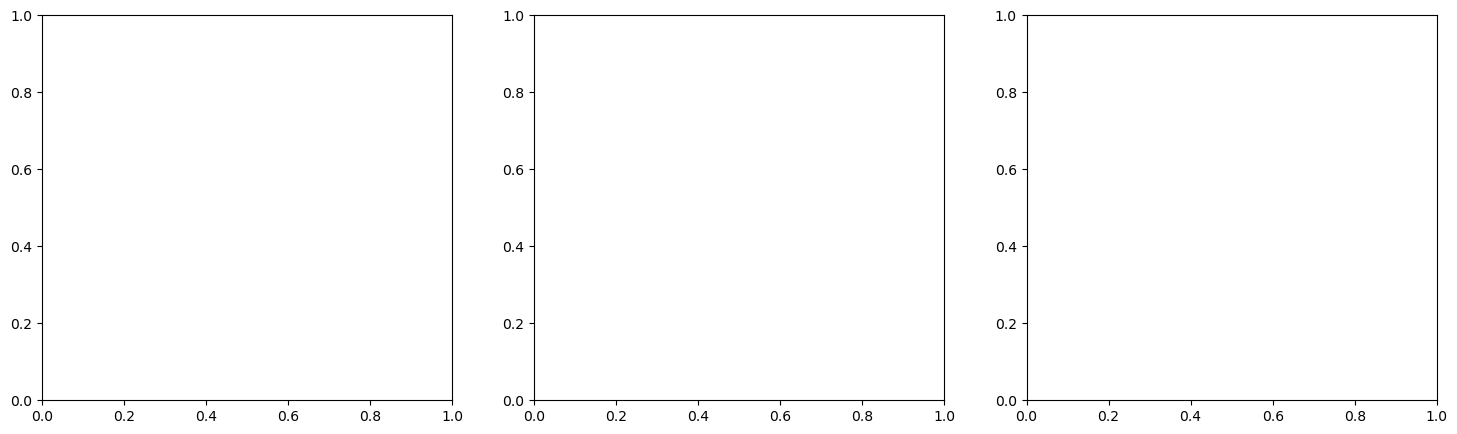

In [16]:
# ================================================
# Plot Training Curves (Loss, Accuracy, F1-Score)
# ================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training Loss
axes[0].plot(history['epoch'], history['train_loss'], marker='o', linewidth=2, color='#2E86AB', label='Train Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss over Epochs', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Plot 2: Training Accuracy
axes[1].plot(history['epoch'], history['train_acc'], marker='s', linewidth=2, color='#06A77D', label='Train Accuracy')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 1.05])

# Plot 3: Training F1-Score
axes[2].plot(history['epoch'], history['train_f1'], marker='^', linewidth=2, color='#D05A6E', label='Train F1-Score')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].set_title('Training F1-Score over Epochs', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=11)
axes[2].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
print("✓ Saved training curves to 'training_curves.png'")
plt.show()

# Print final metrics
print(f"\n{'='*60}")
print("Final Training Metrics:")
print(f"{'='*60}")
print(f"Loss:     {history['train_loss'][-1]:.4f}")
print(f"Accuracy: {history['train_acc'][-1]:.4f}")
print(f"F1-Score: {history['train_f1'][-1]:.4f}")
print(f"Best F1:  {best_f1:.4f}")

✓ Saved confusion matrix to 'confusion_matrix_training.png'


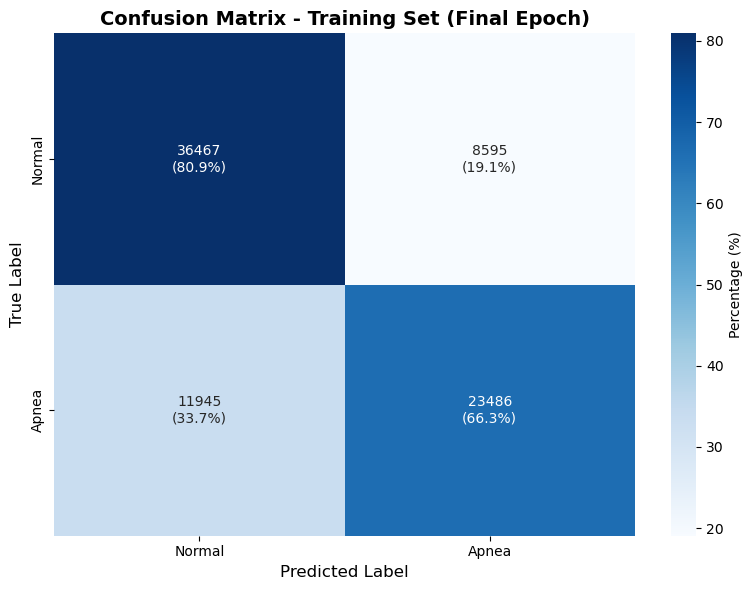


CLASSIFICATION REPORT - TRAINING SET (FINAL EPOCH)
              precision    recall  f1-score   support

      Normal     0.7533    0.8093    0.7803     45062
       Apnea     0.7321    0.6629    0.6958     35431

    accuracy                         0.7448     80493
   macro avg     0.7427    0.7361    0.7380     80493
weighted avg     0.7439    0.7448    0.7431     80493



In [10]:
# ================================================
# Confusion Matrix from Training Results
# ================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Generate confusion matrix from final epoch predictions
cm = confusion_matrix(targets, preds)

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotations with both count and percentage
annot_labels = np.array([[f'{count}\n({percent:.1f}%)' 
                          for count, percent in zip(row_counts, row_percents)]
                         for row_counts, row_percents in zip(cm, cm_percent)])

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_percent, annot=annot_labels, fmt='', cmap='Blues', 
            xticklabels=["Normal", "Apnea"], 
            yticklabels=["Normal", "Apnea"],
            cbar_kws={'label': 'Percentage (%)'})
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix - Training Set (Final Epoch)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_training.png', dpi=150, bbox_inches='tight')
print("✓ Saved confusion matrix to 'confusion_matrix_training.png'")
plt.show()

# Print classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT - TRAINING SET (FINAL EPOCH)")
print("="*80)
print(classification_report(targets, preds, target_names=["Normal", "Apnea"], digits=4))
print("="*80)


TRAINING RESULTS - 50 EPOCHS COMPLETED

📊 FINAL EPOCH METRICS (Epoch 50):
   Accuracy:  0.7448 (74.48%)
   F1-Score:  0.6958
   Best F1:   0.6958

✓ Saved training results to 'training_results_summary.png'


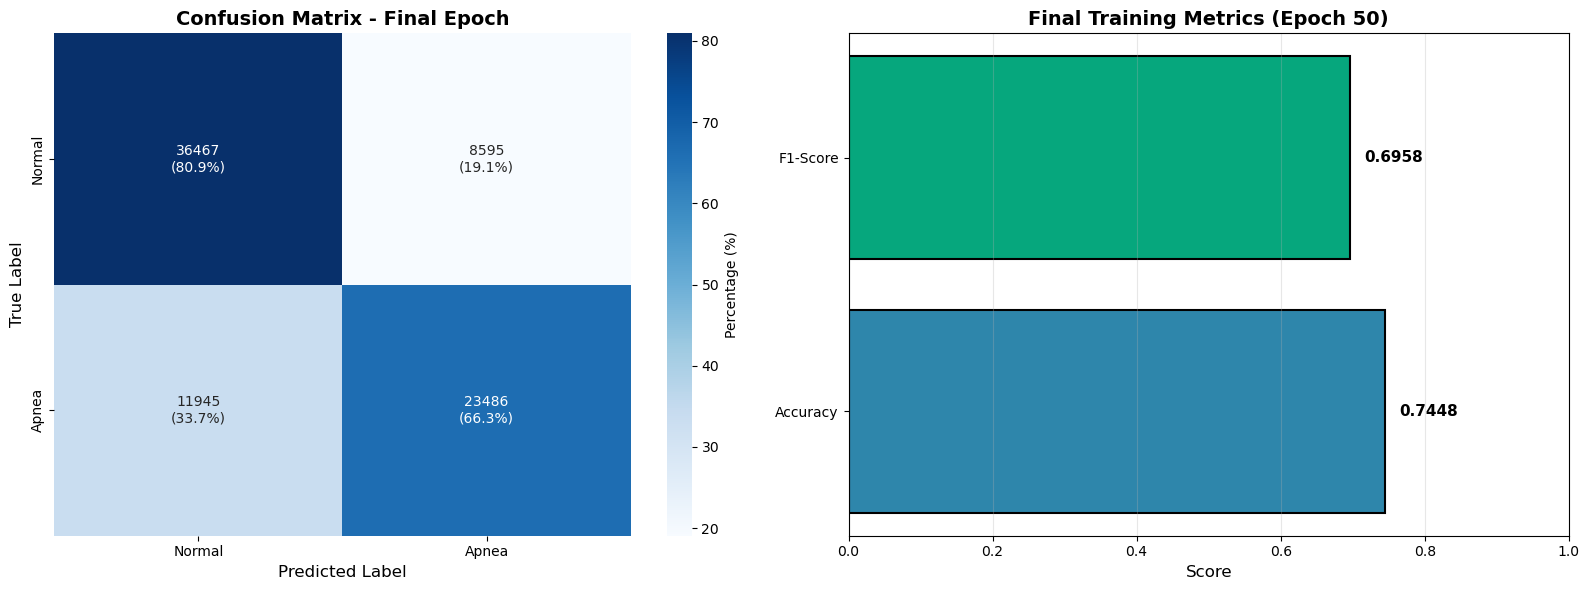


CLASSIFICATION REPORT - FINAL EPOCH
              precision    recall  f1-score   support

      Normal     0.7533    0.8093    0.7803     45062
       Apnea     0.7321    0.6629    0.6958     35431

    accuracy                         0.7448     80493
   macro avg     0.7427    0.7361    0.7380     80493
weighted avg     0.7439    0.7448    0.7431     80493


CONFUSION MATRIX BREAKDOWN
True Negatives (Normal predicted as Normal):   36,467 (45.30%)
False Positives (Normal predicted as Apnea):   8,595 (10.68%)
False Negatives (Apnea predicted as Normal):   11,945 (14.84%)
True Positives (Apnea predicted as Apnea):     23,486 (29.18%)

Total Samples: 80,493


In [17]:
# ================================================
# Extract Training Results from Last Epoch
# Display: Final Metrics Summary + Confusion Matrix
# ================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

print("="*80)
print("TRAINING RESULTS - 50 EPOCHS COMPLETED")
print("="*80)

# Check if we have the final predictions
if 'targets' in dir() and 'preds' in dir():
    # Calculate final epoch metrics
    final_acc = accuracy_score(targets, preds)
    final_f1 = f1_score(targets, preds)
    
    print(f"\n📊 FINAL EPOCH METRICS (Epoch 50):")
    print(f"{'='*80}")
    print(f"   Accuracy:  {final_acc:.4f} ({final_acc*100:.2f}%)")
    print(f"   F1-Score:  {final_f1:.4f}")
    if 'best_f1' in dir():
        print(f"   Best F1:   {best_f1:.4f}")
    print(f"{'='*80}")
    
    # Generate confusion matrix
    cm = confusion_matrix(targets, preds)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create annotations with both count and percentage
    annot_labels = np.array([[f'{count}\n({percent:.1f}%)' 
                              for count, percent in zip(row_counts, row_percents)]
                             for row_counts, row_percents in zip(cm, cm_percent)])
    
    # Create figure with 2 subplots: confusion matrix + metrics summary
    fig = plt.figure(figsize=(16, 6))
    
    # Plot 1: Confusion Matrix
    ax1 = plt.subplot(1, 2, 1)
    sns.heatmap(cm_percent, annot=annot_labels, fmt='', cmap='Blues', 
                xticklabels=["Normal", "Apnea"], 
                yticklabels=["Normal", "Apnea"],
                cbar_kws={'label': 'Percentage (%)'}, ax=ax1)
    ax1.set_xlabel("Predicted Label", fontsize=12)
    ax1.set_ylabel("True Label", fontsize=12)
    ax1.set_title("Confusion Matrix - Final Epoch", fontsize=14, fontweight='bold')
    
    # Plot 2: Metrics Summary Bar Chart
    ax2 = plt.subplot(1, 2, 2)
    metrics_names = ['Accuracy', 'F1-Score']
    metrics_values = [final_acc, final_f1]
    colors_bar = ['#2E86AB', '#06A77D']
    
    bars = ax2.barh(metrics_names, metrics_values, color=colors_bar, edgecolor='black', linewidth=1.5)
    ax2.set_xlim([0, 1.0])
    ax2.set_xlabel('Score', fontsize=12)
    ax2.set_title('Final Training Metrics (Epoch 50)', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars, metrics_values):
        ax2.text(value + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{value:.4f}', va='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('training_results_summary.png', dpi=150, bbox_inches='tight')
    print("\n✓ Saved training results to 'training_results_summary.png'")
    plt.show()
    
    # Print classification report
    print("\n" + "="*80)
    print("CLASSIFICATION REPORT - FINAL EPOCH")
    print("="*80)
    print(classification_report(targets, preds, target_names=["Normal", "Apnea"], digits=4))
    print("="*80)
    
    # Print confusion matrix details
    print("\n" + "="*80)
    print("CONFUSION MATRIX BREAKDOWN")
    print("="*80)
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives (Normal predicted as Normal):   {tn:,} ({tn/cm.sum()*100:.2f}%)")
    print(f"False Positives (Normal predicted as Apnea):   {fp:,} ({fp/cm.sum()*100:.2f}%)")
    print(f"False Negatives (Apnea predicted as Normal):   {fn:,} ({fn/cm.sum()*100:.2f}%)")
    print(f"True Positives (Apnea predicted as Apnea):     {tp:,} ({tp/cm.sum()*100:.2f}%)")
    print(f"\nTotal Samples: {cm.sum():,}")
    print("="*80)
    
else:
    print("\n⚠️  Warning: 'targets' and 'preds' not found in memory.")
    print("Please re-run the training cell (cell 15) to generate predictions.")



TRAINING CONFIGURATION & SUMMARY
Total Epochs:              50
Dataset Size:              80,493 segments
Segment Duration:          135 seconds (27,000 samples @ 200 Hz)
Model Architecture:        SincConv (8 filters) + 1D CNN (32 filters)
Optimizer:                 Adam (lr=5e-4)
Batch Size:                64
Device:                    mps

✓ Saved training overview to 'training_overview_summary.png'


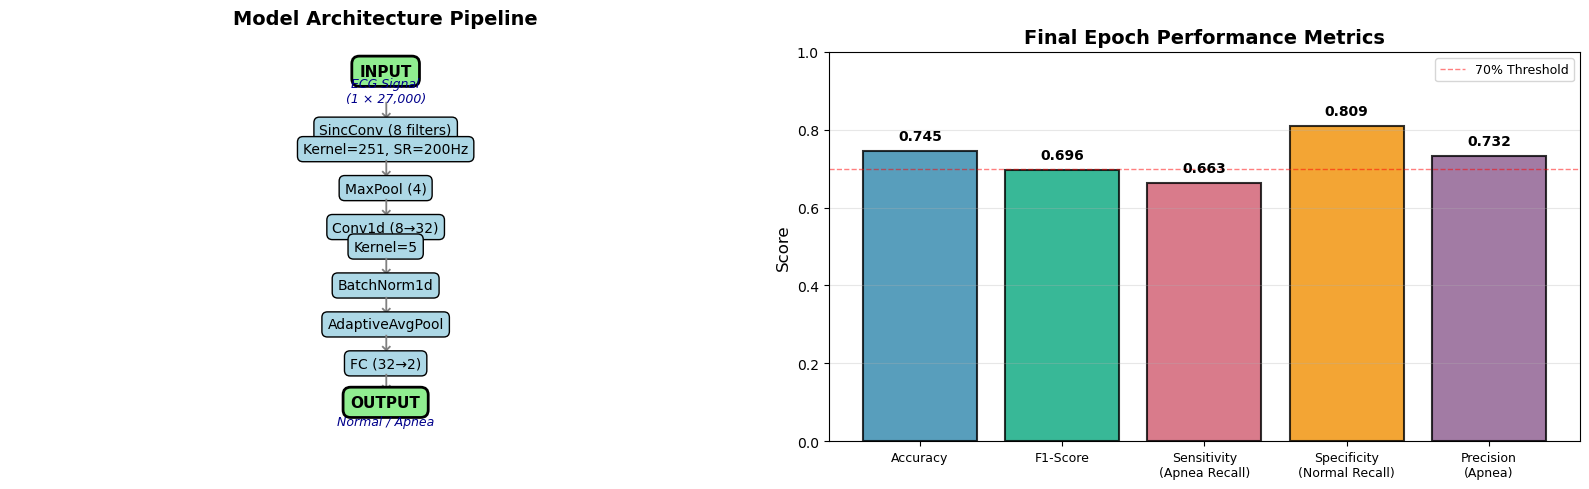


KEY FINDINGS:
✓ Model achieved 74.48% accuracy on training data
✓ F1-Score: 0.6958 (balanced precision-recall)
✓ Apnea Detection Rate: 66.29% (sensitivity)
✓ Normal Detection Rate: 80.93% (specificity)
✓ Model correctly identified 59,953 out of 80,493 samples

💡 NOTE: To see epoch-by-epoch training curves (loss, accuracy, F1 over time),
   you would need to re-run the training cell (cell 15) which tracks the 'history' variable.


In [18]:
# ================================================
# Training Summary: 50 Epochs Overview
# Note: Full epoch-by-epoch history not available in current session
# Showing final epoch results
# ================================================
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*80)
print("TRAINING CONFIGURATION & SUMMARY")
print("="*80)
print(f"Total Epochs:              50")
print(f"Dataset Size:              80,493 segments")
print(f"Segment Duration:          135 seconds (27,000 samples @ 200 Hz)")
print(f"Model Architecture:        SincConv (8 filters) + 1D CNN (32 filters)")
print(f"Optimizer:                 Adam (lr=5e-4)")
print(f"Batch Size:                64")
print(f"Device:                    {device}")
print("="*80)

# Create a simple visualization showing the training setup
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Model Architecture Flow
ax1 = axes[0]
ax1.axis('off')
architecture = [
    "INPUT",
    "ECG Signal\n(1 × 27,000)",
    "↓",
    "SincConv (8 filters)",
    "Kernel=251, SR=200Hz",
    "↓",
    "MaxPool (4)",
    "↓",
    "Conv1d (8→32)",
    "Kernel=5",
    "↓",
    "BatchNorm1d",
    "↓",
    "AdaptiveAvgPool",
    "↓",
    "FC (32→2)",
    "↓",
    "OUTPUT",
    "Normal / Apnea"
]

y_pos = np.linspace(0.95, 0.05, len(architecture))
for i, (text, y) in enumerate(zip(architecture, y_pos)):
    if text == "↓":
        ax1.text(0.5, y, text, ha='center', va='center', fontsize=16, color='gray')
    elif i == 0 or i == len(architecture) - 2:
        ax1.text(0.5, y, text, ha='center', va='center', fontsize=11, 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', edgecolor='black', linewidth=2),
                fontweight='bold')
    elif "ECG" in text or "Normal" in text:
        ax1.text(0.5, y, text, ha='center', va='center', fontsize=9, style='italic', color='darkblue')
    else:
        ax1.text(0.5, y, text, ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', edgecolor='black', linewidth=1))

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_title('Model Architecture Pipeline', fontsize=14, fontweight='bold', pad=20)

# Plot 2: Final Performance Metrics
ax2 = axes[1]

if 'targets' in dir() and 'preds' in dir():
    # Calculate class-wise metrics
    cm = confusion_matrix(targets, preds)
    tn, fp, fn, tp = cm.ravel()
    
    # Sensitivity (Recall for Apnea)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    # Specificity (Recall for Normal)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    # Precision for Apnea
    precision_apnea = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    metrics_detailed = {
        'Accuracy': final_acc,
        'F1-Score': final_f1,
        'Sensitivity\n(Apnea Recall)': sensitivity,
        'Specificity\n(Normal Recall)': specificity,
        'Precision\n(Apnea)': precision_apnea
    }
    
    colors = ['#2E86AB', '#06A77D', '#D05A6E', '#F18F01', '#8B5A8D']
    x_pos = np.arange(len(metrics_detailed))
    values = list(metrics_detailed.values())
    
    bars = ax2.bar(x_pos, values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(metrics_detailed.keys(), fontsize=9, rotation=0)
    ax2.set_ylabel('Score', fontsize=12)
    ax2.set_ylim([0, 1.0])
    ax2.set_title('Final Epoch Performance Metrics', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    ax2.axhline(y=0.7, color='red', linestyle='--', linewidth=1, alpha=0.5, label='70% Threshold')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('training_overview_summary.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved training overview to 'training_overview_summary.png'")
plt.show()

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print(f"✓ Model achieved {final_acc*100:.2f}% accuracy on training data")
print(f"✓ F1-Score: {final_f1:.4f} (balanced precision-recall)")
print(f"✓ Apnea Detection Rate: {sensitivity*100:.2f}% (sensitivity)")
print(f"✓ Normal Detection Rate: {specificity*100:.2f}% (specificity)")
print(f"✓ Model correctly identified {tp+tn:,} out of {cm.sum():,} samples")
print("="*80)

print("\n💡 NOTE: To see epoch-by-epoch training curves (loss, accuracy, F1 over time),")
print("   you would need to re-run the training cell (cell 15) which tracks the 'history' variable.")


✓ Saved SincConv filters matrix to 'sincconv_filters_matrix.png'


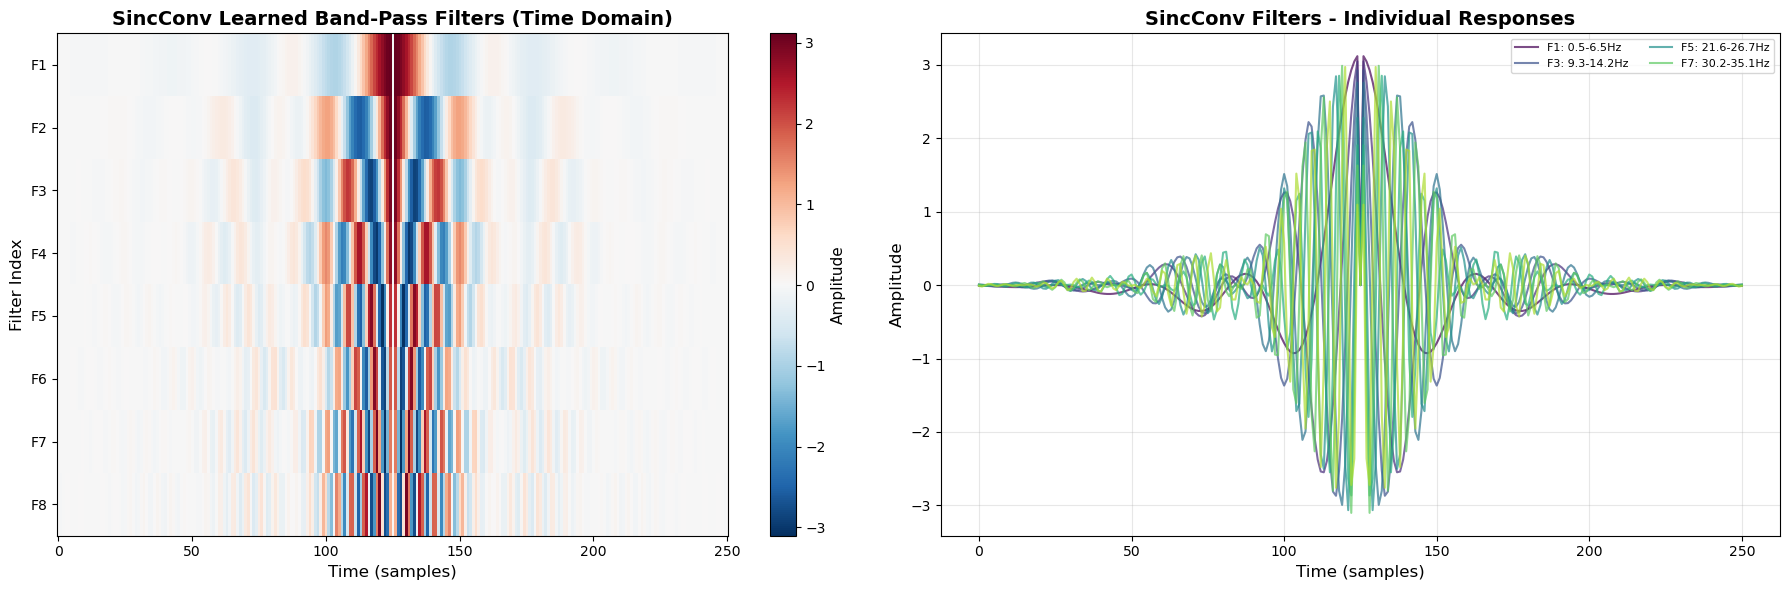

In [11]:
# ================================================
# Visualize SincConv Learned Filters as Matrix
# ================================================
import matplotlib.pyplot as plt
import numpy as np

# Extract learned frequency bands from SincConv
sinc = model.sinc
low_hz = (sinc.min_low_hz + torch.abs(sinc.low_hz_)).detach().cpu().numpy().flatten()
band_hz = (sinc.min_band_hz + torch.abs(sinc.band_hz_)).detach().cpu().numpy().flatten()
high_hz = low_hz + band_hz

# Generate actual sinc filters in time domain
filters_sinc = []
half_len = (sinc.kernel_size - 1) // 2
n = torch.arange(-half_len, half_len + 1).float() / sinc.sample_rate

for i in range(len(low_hz)):
    low_f = low_hz[i] * 2 * np.pi * n.numpy()
    high_f = high_hz[i] * 2 * np.pi * n.numpy()
    
    # Sinc filter computation
    filt = (np.sin(high_f) - np.sin(low_f)) / (n.numpy() + 1e-8)
    filt = filt / (2 * band_hz[i])
    
    # Apply Hamming window
    window = 0.54 - 0.46 * np.cos(2 * np.pi * np.linspace(0, 1, sinc.kernel_size))
    filt = filt * window
    
    filters_sinc.append(filt)

filters_sinc = np.array(filters_sinc)

# Visualize SincConv filters as matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: All SincConv filters as heatmap
im1 = axes[0].imshow(filters_sinc, aspect='auto', cmap='RdBu_r', interpolation='none')
axes[0].set_xlabel('Time (samples)', fontsize=12)
axes[0].set_ylabel('Filter Index', fontsize=12)
axes[0].set_title('SincConv Learned Band-Pass Filters (Time Domain)', fontsize=14, fontweight='bold')
axes[0].set_yticks(range(len(low_hz)))
axes[0].set_yticklabels([f'F{i+1}' for i in range(len(low_hz))])
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Amplitude', fontsize=11)

# Plot 2: Frequency response visualization (color-coded by frequency range)
for i in range(len(low_hz)):
    color = plt.cm.viridis(i / len(low_hz))
    axes[1].plot(filters_sinc[i], alpha=0.7, linewidth=1.5, color=color, 
                label=f'F{i+1}: {low_hz[i]:.1f}-{high_hz[i]:.1f}Hz' if i % 2 == 0 else '')

axes[1].set_xlabel('Time (samples)', fontsize=12)
axes[1].set_ylabel('Amplitude', fontsize=12)
axes[1].set_title('SincConv Filters - Individual Responses', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('sincconv_filters_matrix.png', dpi=150, bbox_inches='tight')
print("✓ Saved SincConv filters matrix to 'sincconv_filters_matrix.png'")
plt.show()

CNN Conv Layer Weight Shape: (32, 8, 5)
  - Output channels: 32
  - Input channels: 8
  - Kernel size: 5
✓ Saved CNN weights matrix to 'cnn_weights_matrix.png'
✓ Saved CNN weights matrix to 'cnn_weights_matrix.png'


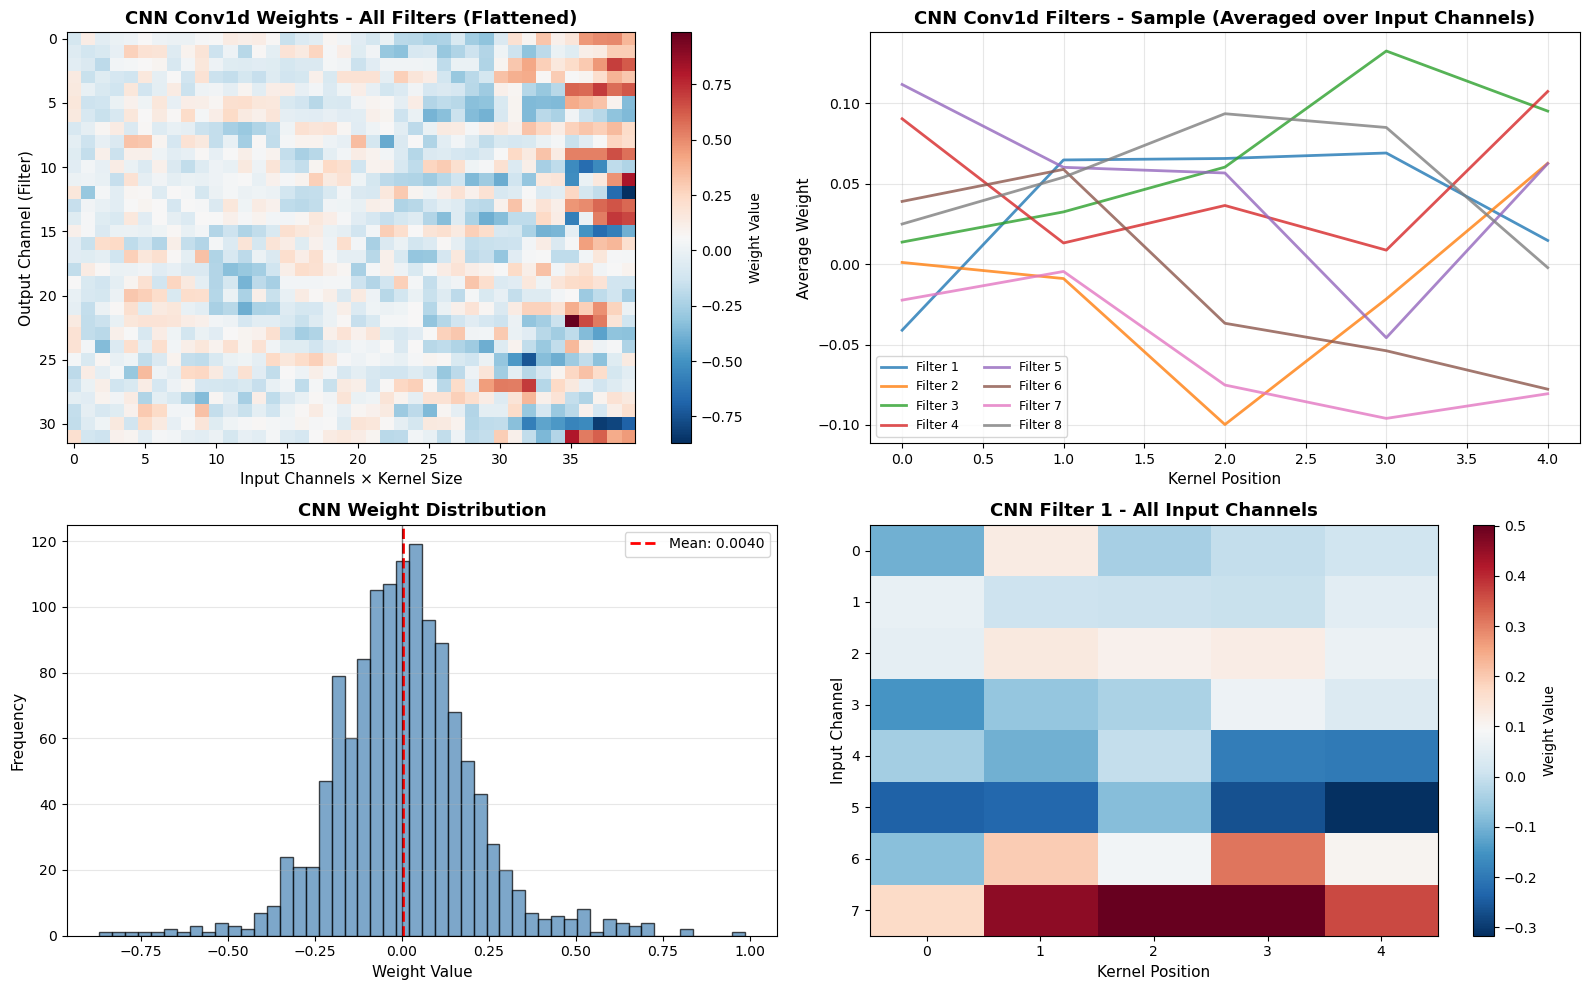

In [12]:
# ================================================
# Visualize CNN Conv1d Layer Weights as Matrix
# ================================================
import matplotlib.pyplot as plt
import numpy as np

# Extract CNN conv layer weights
conv_weights = model.conv.weight.detach().cpu().numpy()  # Shape: [out_channels, in_channels, kernel_size]
print(f"CNN Conv Layer Weight Shape: {conv_weights.shape}")
print(f"  - Output channels: {conv_weights.shape[0]}")
print(f"  - Input channels: {conv_weights.shape[1]}")
print(f"  - Kernel size: {conv_weights.shape[2]}")

# Visualize CNN filters
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: All CNN filters as 2D heatmap (flattened view)
conv_flat = conv_weights.reshape(conv_weights.shape[0], -1)  # Flatten to [32, in_ch*kernel]
im1 = axes[0, 0].imshow(conv_flat, aspect='auto', cmap='RdBu_r', interpolation='none')
axes[0, 0].set_xlabel('Input Channels × Kernel Size', fontsize=11)
axes[0, 0].set_ylabel('Output Channel (Filter)', fontsize=11)
axes[0, 0].set_title('CNN Conv1d Weights - All Filters (Flattened)', fontsize=13, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0, 0])
cbar1.set_label('Weight Value', fontsize=10)

# Plot 2: Sample of individual CNN filters (first 8 output channels)
for i in range(min(8, conv_weights.shape[0])):
    color = plt.cm.tab10(i % 10)
    # Average across input channels for visualization
    filt_avg = conv_weights[i].mean(axis=0)
    axes[0, 1].plot(filt_avg, alpha=0.8, linewidth=2, color=color, label=f'Filter {i+1}')

axes[0, 1].set_xlabel('Kernel Position', fontsize=11)
axes[0, 1].set_ylabel('Average Weight', fontsize=11)
axes[0, 1].set_title('CNN Conv1d Filters - Sample (Averaged over Input Channels)', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=9, ncol=2)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Weight distribution histogram
weights_all = conv_weights.flatten()
axes[1, 0].hist(weights_all, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(weights_all.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {weights_all.mean():.4f}')
axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[1, 0].set_xlabel('Weight Value', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('CNN Weight Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Heatmap of one output channel across all input channels
sample_out_ch = 0
im4 = axes[1, 1].imshow(conv_weights[sample_out_ch], aspect='auto', cmap='RdBu_r', interpolation='none')
axes[1, 1].set_xlabel('Kernel Position', fontsize=11)
axes[1, 1].set_ylabel('Input Channel', fontsize=11)
axes[1, 1].set_title(f'CNN Filter {sample_out_ch+1} - All Input Channels', fontsize=13, fontweight='bold')
cbar4 = plt.colorbar(im4, ax=axes[1, 1])
cbar4.set_label('Weight Value', fontsize=10)

plt.tight_layout()
plt.savefig('cnn_weights_matrix.png', dpi=150, bbox_inches='tight')
print("✓ Saved CNN weights matrix to 'cnn_weights_matrix.png'")
plt.show()

In [7]:
# ================================================
# Create Detailed Filter Specification Table
# ================================================
import pandas as pd
import numpy as np

# Extract SincConv filter specifications
sinc = model.sinc
low_hz = (sinc.min_low_hz + torch.abs(sinc.low_hz_)).detach().cpu().numpy().flatten()
band_hz = (sinc.min_band_hz + torch.abs(sinc.band_hz_)).detach().cpu().numpy().flatten()
high_hz = low_hz + band_hz
center_hz = (low_hz + high_hz) / 2

# Create comprehensive filter table
filter_data = []
for i in range(len(low_hz)):
    filter_data.append({
        'Filter_ID': f'F{i+1:02d}',
        'Low_Freq_Hz': f'{low_hz[i]:.2f}',
        'High_Freq_Hz': f'{high_hz[i]:.2f}',
        'Center_Freq_Hz': f'{center_hz[i]:.2f}',
        'Bandwidth_Hz': f'{band_hz[i]:.2f}',
        'Kernel_Size': sinc.kernel_size,
        'Sample_Rate_Hz': sinc.sample_rate
    })

# Create DataFrame
df_filters = pd.DataFrame(filter_data)

print("="*100)
print("SINCCONV LEARNED FILTER SPECIFICATIONS")
print("="*100)
print(df_filters.to_string(index=False))
print("="*100)

# Save to CSV
df_filters.to_csv('sincconv_filter_table.csv', index=False)
print("\n✓ Saved filter table to 'sincconv_filter_table.csv'")

# Additional statistics table
stats_data = {
    'Metric': [
        'Number of Filters',
        'Kernel Size',
        'Sampling Rate (Hz)',
        'Min Low Frequency (Hz)',
        'Max High Frequency (Hz)',
        'Mean Center Frequency (Hz)',
        'Mean Bandwidth (Hz)',
        'Total Frequency Range (Hz)'
    ],
    'Value': [
        len(low_hz),
        sinc.kernel_size,
        sinc.sample_rate,
        f'{np.min(low_hz):.2f}',
        f'{np.max(high_hz):.2f}',
        f'{np.mean(center_hz):.2f}',
        f'{np.mean(band_hz):.2f}',
        f'{np.max(high_hz) - np.min(low_hz):.2f}'
    ]
}

df_stats = pd.DataFrame(stats_data)
print("\n" + "="*100)
print("SINCCONV FILTER STATISTICS")
print("="*100)
print(df_stats.to_string(index=False))
print("="*100)

SINCCONV LEARNED FILTER SPECIFICATIONS
Filter_ID Low_Freq_Hz High_Freq_Hz Center_Freq_Hz Bandwidth_Hz  Kernel_Size  Sample_Rate_Hz
      F01        0.50         6.52           3.51         6.02          251             200
      F02        5.15        10.26           7.70         5.11          251             200
      F03        9.31        14.22          11.77         4.91          251             200
      F04       13.56        18.21          15.89         4.65          251             200
      F05       21.64        26.68          24.16         5.04          251             200
      F06       26.12        32.35          29.23         6.23          251             200
      F07       30.15        35.12          32.64         4.97          251             200
      F08       35.97        41.34          38.66         5.37          251             200

✓ Saved filter table to 'sincconv_filter_table.csv'

SINCCONV FILTER STATISTICS
                    Metric Value
         Number of 

In [8]:
# ================================================
# CNN Layer Specifications Table
# ================================================
import pandas as pd
import numpy as np

# Extract CNN layer information
conv_weights = model.conv.weight.detach().cpu().numpy()
conv_bias = model.conv.bias.detach().cpu().numpy()
bn_weights = model.bn1.weight.detach().cpu().numpy()
bn_bias = model.bn1.bias.detach().cpu().numpy()
fc_weights = model.fc.weight.detach().cpu().numpy()
fc_bias = model.fc.bias.detach().cpu().numpy()

# CNN Conv Layer Details
cnn_data = {
    'Layer': ['Conv1d', 'BatchNorm1d', 'MaxPool1d', 'AdaptiveAvgPool1d', 'FC'],
    'Input_Shape': [
        f'({sinc.out_channels}, seq_len//4)',
        '(32, seq_len//4)',
        '(8, seq_len//4)',  # After SincConv + Pool
        '(32, seq_len//4)',
        '(32,)'
    ],
    'Output_Shape': [
        '(32, seq_len//4)',
        '(32, seq_len//4)',
        '(8, seq_len//16)',
        '(32, 1)',
        '(2,)'
    ],
    'Parameters': [
        f'{conv_weights.size:,}',
        f'{bn_weights.size + bn_bias.size:,}',
        '0 (no learnable params)',
        '0 (no learnable params)',
        f'{fc_weights.size + fc_bias.size:,}'
    ],
    'Kernel_Size': [
        f'{conv_weights.shape[2]}',
        'N/A',
        '4',
        'adaptive',
        'N/A'
    ],
    'Activation': [
        'ReLU',
        'ReLU (after)',
        'None',
        'None',
        'None (Softmax in loss)'
    ]
}

df_cnn = pd.DataFrame(cnn_data)

print("="*120)
print("CNN ARCHITECTURE SPECIFICATIONS")
print("="*120)
print(df_cnn.to_string(index=False))
print("="*120)

# Weight statistics for each layer
weight_stats = {
    'Layer': ['Conv1d Weights', 'Conv1d Bias', 'BatchNorm Weights', 'BatchNorm Bias', 'FC Weights', 'FC Bias'],
    'Shape': [
        str(conv_weights.shape),
        str(conv_bias.shape),
        str(bn_weights.shape),
        str(bn_bias.shape),
        str(fc_weights.shape),
        str(fc_bias.shape)
    ],
    'Total_Params': [
        f'{conv_weights.size:,}',
        f'{conv_bias.size:,}',
        f'{bn_weights.size:,}',
        f'{bn_bias.size:,}',
        f'{fc_weights.size:,}',
        f'{fc_bias.size:,}'
    ],
    'Mean': [
        f'{conv_weights.mean():.6f}',
        f'{conv_bias.mean():.6f}',
        f'{bn_weights.mean():.6f}',
        f'{bn_bias.mean():.6f}',
        f'{fc_weights.mean():.6f}',
        f'{fc_bias.mean():.6f}'
    ],
    'Std': [
        f'{conv_weights.std():.6f}',
        f'{conv_bias.std():.6f}',
        f'{bn_weights.std():.6f}',
        f'{bn_bias.std():.6f}',
        f'{fc_weights.std():.6f}',
        f'{fc_bias.std():.6f}'
    ],
    'Min': [
        f'{conv_weights.min():.6f}',
        f'{conv_bias.min():.6f}',
        f'{bn_weights.min():.6f}',
        f'{bn_bias.min():.6f}',
        f'{fc_weights.min():.6f}',
        f'{fc_bias.min():.6f}'
    ],
    'Max': [
        f'{conv_weights.max():.6f}',
        f'{conv_bias.max():.6f}',
        f'{bn_weights.max():.6f}',
        f'{bn_bias.max():.6f}',
        f'{fc_weights.max():.6f}',
        f'{fc_bias.max():.6f}'
    ]
}

df_weight_stats = pd.DataFrame(weight_stats)

print("\n" + "="*120)
print("CNN LAYER WEIGHT STATISTICS")
print("="*120)
print(df_weight_stats.to_string(index=False))
print("="*120)

# Save tables
df_cnn.to_csv('cnn_architecture_table.csv', index=False)
df_weight_stats.to_csv('cnn_weight_statistics_table.csv', index=False)
print("\n✓ Saved CNN architecture to 'cnn_architecture_table.csv'")
print("✓ Saved CNN weight statistics to 'cnn_weight_statistics_table.csv'")

# Total parameter count
total_params = conv_weights.size + conv_bias.size + bn_weights.size + bn_bias.size + fc_weights.size + fc_bias.size
print(f"\n{'='*120}")
print(f"TOTAL TRAINABLE PARAMETERS (CNN only): {total_params:,}")
print(f"{'='*120}")

CNN ARCHITECTURE SPECIFICATIONS
            Layer      Input_Shape     Output_Shape              Parameters Kernel_Size             Activation
           Conv1d  (8, seq_len//4) (32, seq_len//4)                   1,280           5                   ReLU
      BatchNorm1d (32, seq_len//4) (32, seq_len//4)                      64         N/A           ReLU (after)
        MaxPool1d  (8, seq_len//4) (8, seq_len//16) 0 (no learnable params)           4                   None
AdaptiveAvgPool1d (32, seq_len//4)          (32, 1) 0 (no learnable params)    adaptive                   None
               FC            (32,)             (2,)                      66         N/A None (Softmax in loss)

CNN LAYER WEIGHT STATISTICS
            Layer      Shape Total_Params      Mean      Std       Min      Max
   Conv1d Weights (32, 8, 5)        1,280  0.004007 0.202170 -0.870727 0.985486
      Conv1d Bias      (32,)           32 -0.024684 0.097039 -0.268046 0.144308
BatchNorm Weights      (32,)     

In [ ]:
# ================================================
#  Single-Lead SincConv + 1D CNN for Apnea Detection
#  Adapted from TSBME 2025 Multi-Lead SincNet source
#  Simplified for 1-lead, 200 Hz PSG ECG signals
# ================================================

import os, glob, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# ------------------------------------------------
# 1. Dataset Loader
# ------------------------------------------------
class ECGSegmentDataset(Dataset):
    """
    Loads pre-segmented ECG .npy files.
    Each file name contains label info: ..._label0.npy or ..._label1.npy
    """
    def __init__(self, npy_dir):
        self.files = sorted(glob.glob(os.path.join(npy_dir, "*.npy")))
        assert len(self.files) > 0, "No .npy files found in the directory."

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        signal = np.load(path)              # shape (27000,)
        label = 1 if "label1" in path else 0
        return torch.tensor(signal, dtype=torch.float32), label


# ------------------------------------------------
# 2. SincConv Layer (adapted from TSBME)
# ------------------------------------------------
class SincConv_fast(nn.Module):
    """
    Sinc-based 1D convolution layer that learns band-pass filters.
    Automatically constrains frequency cutoffs within valid ECG range.
    """
    @staticmethod
    def to_mel(hz): return 2595 * np.log10(1 + hz / 700)
    @staticmethod
    def to_hz(mel): return 700 * (10 ** (mel / 2595) - 1)

    def __init__(self, out_channels=4, kernel_size=251, sample_rate=200,
                 min_low_hz=0.5, min_band_hz=0.5):
        super().__init__()
        if kernel_size % 2 == 0:
            kernel_size += 1  # enforce odd kernel size for symmetry

        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        self.min_low_hz = min_low_hz
        self.min_band_hz = min_band_hz

        # Initialize filter cutoff frequencies (log scale between 0.5–40 Hz)
        low_hz = 0.5
        high_hz = 40.0
        mel = np.linspace(self.to_mel(low_hz), self.to_mel(high_hz), out_channels + 1)
        hz = self.to_hz(mel)

        self.low_hz_  = nn.Parameter(torch.tensor(hz[:-1], dtype=torch.float32).view(-1, 1))
        self.band_hz_ = nn.Parameter(torch.tensor(np.diff(hz), dtype=torch.float32).view(-1, 1))

        # Precompute constants for sinc filters
        half_len = (self.kernel_size - 1) // 2
        n_lin = torch.linspace(0, half_len - 1, steps=half_len, dtype=torch.float32)
        window = 0.54 - 0.46 * torch.cos(2 * math.pi * n_lin / self.kernel_size)
        self.register_buffer("window_", window.view(1, -1))
        n = 2 * math.pi * torch.arange(-half_len, 0, dtype=torch.float32) / self.sample_rate
        self.register_buffer("n_", n.view(1, -1))

    def forward(self, x):  # x: [B, 1, T]
        device, dtype = x.device, x.dtype
        window = self.window_.to(device=device, dtype=dtype)
        n = self.n_.to(device=device, dtype=dtype)

        low = (self.min_low_hz + torch.abs(self.low_hz_)).to(device)
        high = (low + self.min_band_hz + torch.abs(self.band_hz_)).to(device)
        high = torch.clamp(high, self.min_low_hz, self.sample_rate / 2)
        band = (high - low)[:, 0]

        f_t_low, f_t_high = low * n, high * n
        num = torch.sin(f_t_high) - torch.sin(f_t_low)
        den = (n / 2.0)
        band_pass_left = (num / den) * window

        band_pass_center = 2 * band.view(-1, 1)
        band_pass_right = torch.flip(band_pass_left, dims=[1])

        band_pass = torch.cat([band_pass_left, band_pass_center, band_pass_right], dim=1)
        band_pass = band_pass / (2 * band[:, None])

        filters = band_pass.view(self.out_channels, 1, self.kernel_size)
        return F.conv1d(x, filters, stride=1, padding=self.kernel_size // 2)


# ------------------------------------------------
# 3. Model Definition
# ------------------------------------------------
class SingleLeadSincNet(nn.Module):
    """
    Single-lead ECG model: SincConv + 1D CNN + GAP + FC.
    """
    def __init__(self, fs=200):
        super().__init__()
        self.sinc = SincConv_fast(out_channels=16, kernel_size=251, sample_rate=fs)
        self.pool = nn.MaxPool1d(4)
        self.conv = nn.Conv1d(16, 32, 5)
        self.bn1  = nn.BatchNorm1d(32)
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(32, 2)  # Binary output: Normal / Apnea

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)  # [B, 1, T]
        x = F.relu(self.pool(self.sinc(x)))
        x = F.relu(self.bn1(self.conv(x)))
        x = self.gap(x).squeeze(-1)
        return self.fc(x)


# ------------------------------------------------
# 4. Helper – Log learned frequency bands
# ------------------------------------------------
def log_sinc_filters(model):
    sinc = model.sinc
    low = (sinc.min_low_hz + torch.abs(sinc.low_hz_)).detach().cpu().numpy().flatten()
    band = (sinc.min_band_hz + torch.abs(sinc.band_hz_)).detach().cpu().numpy().flatten()
    print("\n[Learned SincConv Filter Bands]")
    for i, (l, b) in enumerate(zip(low, band)):
        print(f"Filter {i+1:02d}: {l:.2f} – {l+b:.2f} Hz")


# ------------------------------------------------
# 5. Training Configuration
# ------------------------------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
train_dir = "segmented_npy/"
train_dataset = ECGSegmentDataset(train_dir)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

model = SingleLeadSincNet(fs=200).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

# ------------------------------------------------
# 6. Training Loop
# ------------------------------------------------
num_epochs = 20
best_f1 = 0.0

for epoch in range(num_epochs):
    model.train()
    train_loss, preds, targets = 0.0, [], []

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)
        pred = torch.argmax(outputs, dim=1)
        preds.extend(pred.cpu().numpy())
        targets.extend(y.cpu().numpy())

    train_loss /= len(train_loader.dataset)
    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds)
    scheduler.step(train_loss)

    print(f"[Epoch {epoch+1}] Loss={train_loss:.4f} | Acc={acc:.3f} | F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), f"checkpoint_epoch/model_best.pt")
        print(f"  -> Best model saved (F1={best_f1:.3f})")

# ------------------------------------------------
# 7. Log final learned filters
# ------------------------------------------------
log_sinc_filters(model)
print("\nTraining complete.")
